### Exercise 5.1

<br>

1) Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.

2) Pick data from the following columns to a second dataframe `df2`: `y`, `job`, `marital`, `default`, `housing`, `poutcome`.

3) Convert categorical variables to dummy numerical values using the command

`df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])`

4) Produce a heat map of correlation coefficients for all variables in `df3`. Describe the amount of correlation between the variables in your own words.

5) Select the column called `y` of `df3` as the target variable `y`, and all the remaining columns for the explanatory variables `X`.

6) Split the dataset into training and testing sets with 75/25  ratio.

7) Setup a logistic regression model, train it with training data and predict on testing data.

8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.


### Exercise 5.2

Consider the data from CSV file `weight-height.csv`.

1) Read data into a pandas dataframe.

2) Pick the target variable `y` as weight in kilograms, and the feature variable `X` as height in centimeters.

3) Split the data into training and testing sets with 80/20 ratio.

4) Scale the training and testing data using normalization and standardization.

5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.



Answer 5.1.1 > Import CSV file, and using delimeter to split data from csv

In [179]:
import pandas as pd

df = pd.read_csv('bank.csv', delimiter=';')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Answer 5.1.2 > Select specific columns

In [180]:
keep = ['y','job','marital','default','housing','poutcome']

df2 = df[keep]
df2.head()

,y,job,marital,default,housing,poutcome
0,no,unemployed,married,no,no,unknown
1,no,services,married,no,yes,failure
2,no,management,single,no,yes,failure
3,no,management,married,no,yes,unknown
4,no,blue-collar,married,no,yes,unknown


Answer 5.1.3 > Get dummies from the y column

In [181]:
df3 = pd.get_dummies(df2, columns=['job','marital','default','housing','poutcome'])

df3.head()

,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,marital_married,marital_single,default_no,default_yes,housing_no,housing_yes,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,no,False,False,False,False,False,False,False,False,False,...,True,False,True,False,True,False,False,False,False,True
1,no,False,False,False,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
2,no,False,False,False,False,True,False,False,False,False,...,False,True,True,False,False,True,True,False,False,False
3,no,False,False,False,False,True,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True
4,no,False,True,False,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,False,True


Answer 5.1.4 > Plot a correlation heatmap

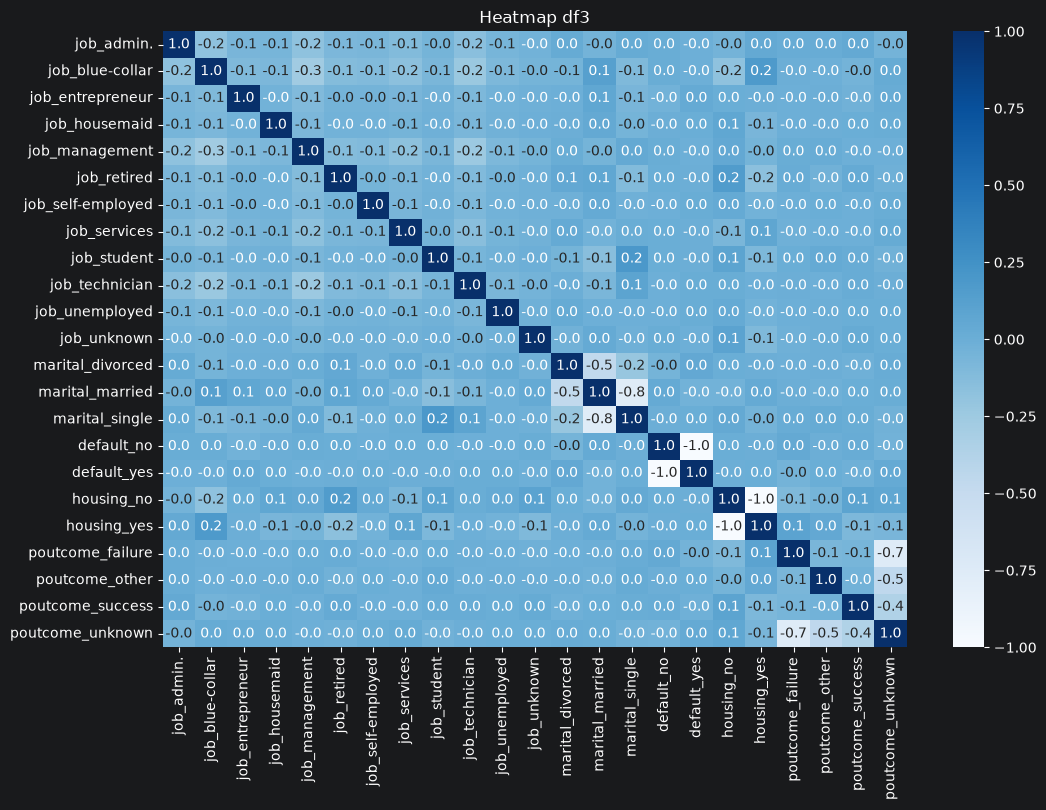

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
corr_df3 = df3.corr(numeric_only=True)
sns.heatmap(corr_df3, annot=True, fmt=".1f",cmap='Blues')
plt.title("Heatmap df3")
plt.show()

Answer 5.1.5 > Define target y

In [183]:
y = df3['y']
X = df3.drop(columns=['y'])

Answer 5.1.6 > Split into training and testing

In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Answer 5.1.7 Train logistic regression and evaluate

In [185]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

mod1 = LogisticRegression(max_iter=1000)
mod1.fit(X_train, y_train)

y_pred = mod1.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

cm

array([[997,   9],
       [106,  19]])

Answer 5.1.8 > Print the confusion matrix

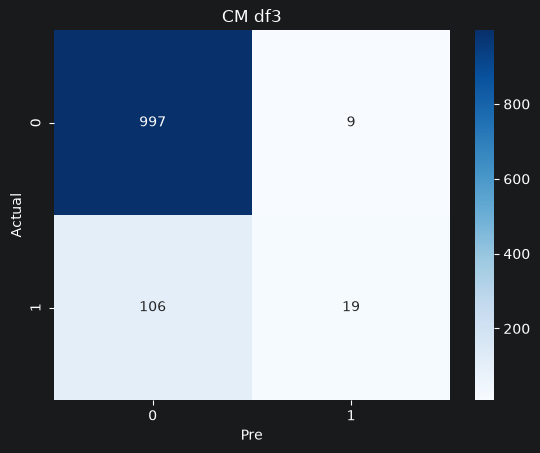

In [186]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Pre')
plt.ylabel('Actual')
plt.title('CM df3')
plt.show()

Answer 5.2.1, 5.2.2 > Import CSV file, select column and covert pound to kg. ince to cm.

In [187]:
df4 = pd.read_csv('weight-height.csv')

X = df4[['Height']]*2.54
y = df4['Weight']*0.45359237

Answer 5.2.3 > Split the data into training and testing

In [188]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X,y,test_size=0.20, random_state=42)

Answer 5.2.4 > Scale the training and testing by norm and standd

In [189]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler()
X1_train_norm = min_max_scaler.fit_transform(X1_train)
X1_test_norm = min_max_scaler.transform(X1_test)

std_scaler = StandardScaler()
X1_train_std = std_scaler.fit_transform(X1_train)
X1_test_std = std_scaler.transform(X1_test)

Answer 5.2.5 > Fit a knn regression model with k=5

In [190]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X1_train, y1_train)

y1_pred = knn.predict(X1_test)

r2_unscaled = r2_score(y1_test, y1_pred)
print(f"R square value o: {r2_unscaled:.4f}")

R square value o: 0.8346
